## Nuclear Starburst Disks – Plots

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-3, 3)
plt.rcParams['figure.figsize'] = [7, 4.5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

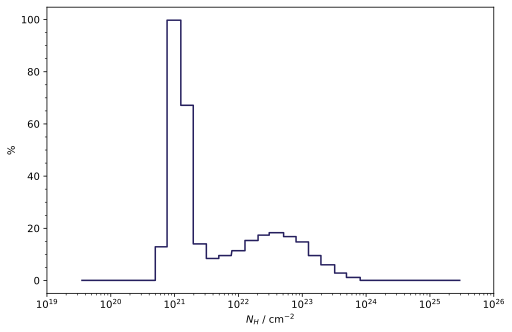

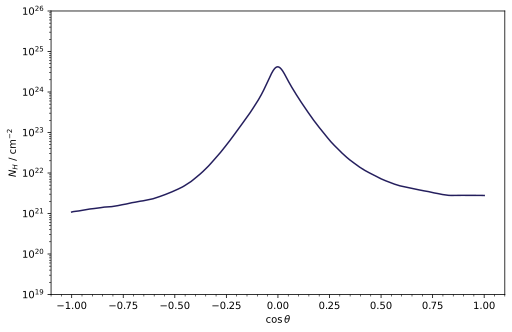

In [2]:
x0, y0 = np.genfromtxt('data/hist.txt', unpack=True)
x1, y1 = np.genfromtxt('data/dens.txt', unpack=True)

from scipy.signal import savgol_filter
y1 = savgol_filter(y1, window_length=10, polyorder=2)

from scipy.interpolate import make_interp_spline
spl = make_interp_spline(x1, y1, k=3)

x1 = np.linspace(-1, 1, 1000)
y1 = spl(x1)

y0 *= 100
x0, y1 = 10**x0, 10**y1

plt.plot(x0, y0, c=(36/255, 30/255, 93/255))

plt.xlim(1e19, 1e26)
plt.xscale('log')

plt.xlabel(r'$N_H$ / cm$^{-2}$')
plt.ylabel(r'$\%$')

plt.savefig(f'content/hist.pdf')
plt.show()
plt.close()

plt.plot(x1, y1, c=(36/255, 30/255, 93/255))

plt.ylim(1e19, 1e26)
plt.yscale('log')

plt.xlabel(r'$\cos\theta$')
plt.ylabel(r'$N_H$ / cm$^{-2}$')

plt.savefig(f'content/dens.pdf')
plt.show()
plt.close()